# Step 02 — Fusion Freeze and Bounded Confirmation

## tl;dr

This validation-only notebook confirms one already-selected Mark 4E inference policy. It recomputes control and recall-loss model scores from their checkpoints, verifies deterministic repeated inference and equivalence to the historical Mark 4D caches, applies pixelwise maximum fusion and global threshold `0.70` unchanged, reproduces all six temporary validation targets, reports patient-bootstrap uncertainty, and freezes the complete inference policy if every mandatory condition passes.

**Execution status on delivery:** structurally validated and safely preflighted, but intentionally not fully executed. Use **Restart Kernel and Run All**. This notebook performs four full validation inference passes (two checkpoints, each repeated once) and can take substantial GPU time.

**Test lock:** test rows may be counted as manifest metadata only. No test image, mask, loader, statistic, threshold, or decision is accessed.

## Context & Methods

### Frozen candidate

- Control checkpoint: `mark_4_outputs/mark_4_best.pth`.
- Recall-loss checkpoint: `mark_4c_outputs/recall_loss_best.pth`.
- Input: one-channel derived CT normalized from the broad `[-160, 240]` HU window.
- ROI: frozen predicted-liver bounding box, threshold `0.50`, largest 3D component, padding `16`.
- Fusion: `p_fused(x) = max(p_control(x), p_recall(x))`.
- Hard threshold: `0.70`.
- Post-processing: none beyond ROI inverse mapping.
- Mean patient Dice population: nine tumour-positive validation patients.

### Key Assumptions

- Step 01 must have passed before inference begins.
- No threshold, fusion weight, checkpoint, post-processing, or patient-specific rule may be selected here.
- Threshold `0.65` is a predeclared sensitivity report only and cannot replace `0.70`.
- Historical float16 caches are comparison evidence; fresh checkpoint inference is authoritative for confirmation.
- Sigmoid outputs are called model probability scores unless reliability evidence is explicitly reported.
- Bootstrap resampling uses the patient as the unit and does not create a new pass threshold.

## Data

### 1. Imports, paths, frozen parameters, and output contract

In [1]:
from __future__ import annotations

import hashlib, json, math, platform, sys, time, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
import torch
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
PART2_ROOT = PROJECT_ROOT / "mark 1 (part 2)"
PHASE_DIR = PART2_ROOT / "step_02_fusion_freeze_confirmation"
OUTPUT_DIR = PHASE_DIR / "outputs"
FRESH_CACHE_DIR = OUTPUT_DIR / "probability_cache"
DATASET_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260713_214847_v2")
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
EXPECTED_MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
MARK4_DIR = PROJECT_ROOT / "mark 1" / "mark_4_outputs"
MARK4C_DIR = PROJECT_ROOT / "mark 1" / "mark_4c_outputs"
MARK4D_DIR = PROJECT_ROOT / "mark 1" / "mark_4d_outputs"
MARK4E_DIR = PROJECT_ROOT / "mark 1" / "mark_4e_outputs"
STEP01_OUTPUTS = PART2_ROOT / "step_01_pretraining_dataset_characterization" / "outputs"
CHECKPOINTS = {"control": MARK4_DIR / "mark_4_best.pth", "recall_loss": MARK4C_DIR / "recall_loss_best.pth"}
HISTORICAL_CACHE_DIR = MARK4D_DIR / "probability_cache"
VAL_ROI_PATH = MARK4_DIR / "validation_roi_manifest.csv"

FROZEN_POLICY = "maximum"
FROZEN_THRESHOLD = 0.70
SENSITIVITY_THRESHOLDS = [0.65, 0.70]
TARGETS = {"mean_patient_dice": 0.3329, "volume_104_dice": 0.05, "volume_116_dice": 0.01,
           "q1_detected_pct": 35.0, "positive_predicted_empty_pct": 35.0, "empty_slice_false_positive_pct": 20.0}
LOWER_IS_BETTER = {"positive_predicted_empty_pct", "empty_slice_false_positive_pct"}
RANDOM_SEED = 42
BOOTSTRAP_ITERATIONS = 10000
DICE_EPSILON = 1e-6
BATCH_SIZE = 24
NUM_WORKERS = 0
CACHE_MAX_ABS_TOLERANCE = 5e-4
CACHE_MEAN_ABS_TOLERANCE = 1e-4
CACHE_FRACTION_ABOVE_TOLERANCE = 1e-4
HARD_PREDICTION_DISAGREEMENT_TOLERANCE = 1e-6
DETERMINISM_MAX_ABS_TOLERANCE = 1e-6
REFERENCE_METRIC_ABS_TOLERANCE = 5e-4
SCORE_HISTOGRAM_BINS = np.linspace(0.0, 1.0, 21)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_IMAGES_ACCESSED = False

EXPECTED_OUTPUTS = [
    "configuration.json", "provenance.json", "checkpoint_hashes.json", "cache_integrity.csv",
    "fresh_vs_historical_cache_equivalence.csv", "hard_prediction_equivalence.csv", "determinism_check.csv", "runtime_log.csv",
    "patient_metrics.csv", "slice_metrics.csv", "lesion_or_size_metrics.csv", "size_stratum_metrics.csv",
    "bootstrap_uncertainty.csv", "threshold_sensitivity.csv", "probability_histograms.csv",
    "probability_reliability.csv", "selected_gate_table.csv", "expected_vs_actual.csv",
    "fusion_confirmation_dashboard.png", "selected_policy_patient_heatmap.png",
    "probability_diagnostics_dashboard.png", "v104_localization.png", "v116_localization.png",
    "immutable_inference_policy.json", "gate_result.json"
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FRESH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
assert OUTPUT_DIR.resolve().parent == PHASE_DIR.resolve()
assert TEST_IMAGES_ACCESSED is False
print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("Frozen policy:", FROZEN_POLICY, "threshold:", FROZEN_THRESHOLD)

Device: cuda
Output directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1 (part 2)\step_02_fusion_freeze_confirmation\outputs
Frozen policy: maximum threshold: 0.7


### 2. Deterministic helpers and metric definitions

In [2]:
def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2, sort_keys=True, default=str), encoding="utf-8")

def save_csv(frame: pd.DataFrame, name: str) -> None:
    frame.to_csv(OUTPUT_DIR / name, index=False, float_format="%.8f")

def resize_float(array, size=(256, 256)):
    return np.asarray(Image.fromarray(array.astype(np.float32), mode="F").resize(size, Image.Resampling.BILINEAR), dtype=np.float32)

def probability_to_full(probability, box):
    y0, y1, x0, x1 = map(int, box)
    resized = resize_float(probability, (x1-x0, y1-y0))
    full = np.zeros((256, 256), np.float32)
    full[y0:y1, x0:x1] = resized
    return full

def dice_from_counts(intersection, truth_pixels, predicted_pixels):
    return float((2*intersection + DICE_EPSILON) / (truth_pixels + predicted_pixels + DICE_EPSILON))

def target_pass(metric, value):
    return bool(value <= TARGETS[metric] if metric in LOWER_IS_BETTER else value >= TARGETS[metric])

def bootstrap_mean(values, iterations=BOOTSTRAP_ITERATIONS, seed=RANDOM_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(iterations, len(values)), replace=True).mean(axis=1)
    return {"estimate": float(values.mean()), "ci_lower_2_5": float(np.quantile(samples, .025)),
            "ci_upper_97_5": float(np.quantile(samples, .975)), "iterations": iterations,
            "resampling_unit": "tumour_positive_validation_patient", "seed": seed}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

### 3. Verify Step 01, manifest, checkpoints, schemas, and sealed test state

In [3]:
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

manifest_hash = sha256_file(MANIFEST_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
step01_gate = json.loads((STEP01_OUTPUTS / "pretraining_dataset_gate.json").read_text(encoding="utf-8"))
assert step01_gate["all_mandatory_targets_passed"] is True
assert step01_gate["decision"] == "PASS_FREEZE_DATA_CARD_AND_PROCEED_TO_FUSION_CONFIRMATION"
assert step01_gate["test_images_accessed"] is False

manifest_all = pd.read_csv(MANIFEST_PATH)
test_metadata = manifest_all.loc[manifest_all.split.eq("test"), ["sample_id", "volume_id", "split"]].copy()
val_rows = manifest_all.loc[manifest_all.split.eq("val")].sort_values(["volume_id", "slice_index"]).reset_index(drop=True)
del manifest_all
assert len(val_rows) == 10685 and val_rows.volume_id.nunique() == 13
assert set(val_rows.split.unique()) == {"val"} and not val_rows.split.eq("test").any()
positive_volumes = sorted(val_rows.loc[val_rows.tumor_pixels.gt(0), "volume_id"].unique().tolist())
assert len(positive_volumes) == 9 and {104, 116} <= set(positive_volumes)
q1_limit = float(val_rows.loc[val_rows.tumor_pixels.gt(0), "tumor_pixels"].quantile(.25))

val_rois = pd.read_csv(VAL_ROI_PATH)
assert len(val_rois) == 13 and set(val_rois.volume_id) == set(val_rows.volume_id.unique())
assert np.allclose(val_rois.liver_threshold, .50) and (val_rois.padding == 16).all() and val_rois.component_mode.eq("largest_3d").all()
assert val_rois.tumor_pixel_containment.dropna().min() == 1.0

checkpoint_hashes = {name: sha256_file(path) for name, path in CHECKPOINTS.items()}
for name, path in CHECKPOINTS.items():
    assert path.is_file()
    payload = torch.load(path, map_location="cpu", weights_only=False)
    assert payload["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
    assert "model_state" in payload
write_json(OUTPUT_DIR / "checkpoint_hashes.json", checkpoint_hashes)

mark4e_gate = json.loads((MARK4E_DIR / "mark_4e_gate_result.json").read_text(encoding="utf-8"))
assert mark4e_gate["selected_policy"] == FROZEN_POLICY
assert np.isclose(mark4e_gate["selected_threshold"], FROZEN_THRESHOLD, atol=1e-6)
assert mark4e_gate["targets_passed"] == 6 and mark4e_gate["test_images_accessed"] is False

historical_cache_paths = {name: {int(path.stem.split("_")[-1]): path for path in (HISTORICAL_CACHE_DIR/name).glob("volume_*.npz")} for name in CHECKPOINTS}
assert set(historical_cache_paths["control"]) == set(historical_cache_paths["recall_loss"]) == set(val_rows.volume_id.unique())
assert TEST_IMAGES_ACCESSED is False

configuration = {
    "phase": "step_02_fusion_freeze_confirmation", "mode": "VALIDATION_CONFIRMATION",
    "manifest_path": str(MANIFEST_PATH), "manifest_sha256": manifest_hash,
    "allowed_splits": ["val"], "validation_rows": len(val_rows), "validation_volumes": val_rows.volume_id.nunique(),
    "positive_patient_definition": positive_volumes, "q1_positive_slice_pixel_limit": q1_limit,
    "checkpoints": {k: str(v) for k,v in CHECKPOINTS.items()}, "checkpoint_sha256": checkpoint_hashes,
    "input": {"source": "derived 256x256 PNG", "broad_window_hu": [-160,240], "normalization": "uint8/255", "channels": ["broad"]},
    "roi": {"source": str(VAL_ROI_PATH), "threshold": .50, "component_rule": "largest_3d", "padding": 16,
            "crop_resize": [256,256], "image_interpolation": "bilinear", "inverse_mapping": "bilinear score resize into frozen full-image box"},
    "model": {"architecture": "MobileNetV2UNet", "input_channels": 1, "output_channels": 1, "strict_state_loading": True},
    "score": {"definition": "sigmoid(logit)", "dtype_during_inference": "float32", "saved_dtype": "float16"},
    "fusion": {"policy": FROZEN_POLICY, "equation": "maximum(control_probability, recall_probability)", "weights": None},
    "threshold": FROZEN_THRESHOLD, "sensitivity_thresholds_report_only": SENSITIVITY_THRESHOLDS,
    "post_processing": "none", "targets": TARGETS, "metric_epsilon": DICE_EPSILON,
    "bootstrap": {"iterations": BOOTSTRAP_ITERATIONS, "seed": RANDOM_SEED, "unit": "patient"},
    "tolerances": {"cache_max_abs_diagnostic": CACHE_MAX_ABS_TOLERANCE, "cache_mean_abs": CACHE_MEAN_ABS_TOLERANCE,
                   "cache_fraction_above_max_abs": CACHE_FRACTION_ABOVE_TOLERANCE,
                   "hard_prediction_disagreement_fraction": HARD_PREDICTION_DISAGREEMENT_TOLERANCE,
                   "determinism_max_abs": DETERMINISM_MAX_ABS_TOLERANCE, "reference_metric_abs": REFERENCE_METRIC_ABS_TOLERANCE},
    "device": str(DEVICE), "batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS,
    "random_seed": RANDOM_SEED, "test_images_accessed": False, "full_analysis_executed": False,
    "expected_outputs": EXPECTED_OUTPUTS
}
write_json(OUTPUT_DIR / "configuration.json", configuration)
print("SAFE PREFLIGHT PASS: Step 01, manifest, checkpoint payloads, ROI rule, historical caches, and test lock verified.")

SAFE PREFLIGHT PASS: Step 01, manifest, checkpoint payloads, ROI rule, historical caches, and test lock verified.


### 4. Build the ordered frozen validation ROI dataset

In [4]:
class VolumeROIDataset(Dataset):
    def __init__(self, rows, roi):
        self.rows = rows.reset_index(drop=True)
        self.roi = roi
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows.iloc[index]
        box = np.array([self.roi.y0, self.roi.y1, self.roi.x0, self.roi.x1], dtype=np.int64)
        y0,y1,x0,x1 = box
        with Image.open(DATASET_ROOT / row.image_path) as handle:
            image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
        with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
            truth = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
        with Image.open(DATASET_ROOT / row.organ_mask_path) as handle:
            organ = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
        crop = resize_float(image[y0:y1, x0:x1])[None].copy()
        return {"image": torch.from_numpy(crop), "truth": torch.from_numpy(truth), "organ": torch.from_numpy(organ),
                "sample_id": row.sample_id, "volume_id": int(row.volume_id), "slice_index": int(row.slice_index), "box": torch.from_numpy(box)}

def load_model(checkpoint_path):
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model = MobileNetV2UNet(1, 1, False)
    model.load_state_dict(payload["model_state"], strict=True)
    return model.to(DEVICE).eval()

sample_volume = int(val_rows.volume_id.min())
sample_rows = val_rows[val_rows.volume_id.eq(sample_volume)]
sample_roi = val_rois.set_index("volume_id").loc[sample_volume]
sample_item = VolumeROIDataset(sample_rows, sample_roi)[0]
assert sample_item["image"].shape == (1,256,256) and sample_item["truth"].shape == (256,256)
print("PASS: representative validation item and frozen ROI geometry verified.")

PASS: representative validation item and frozen ROI geometry verified.


## Results

### 5. Fresh checkpoint inference, deterministic repeat, and historical-cache equivalence

In [5]:
def infer_volume(model, loader):
    scores, truths, organs, slice_indices, sample_ids = [], [], [], [], []
    with torch.inference_mode():
        for batch in loader:
            batch_scores = torch.sigmoid(model(batch["image"].to(DEVICE)))[:,0].cpu().numpy()
            for i in range(len(batch_scores)):
                scores.append(probability_to_full(batch_scores[i], batch["box"][i].numpy()))
                truths.append(batch["truth"][i].numpy().astype(bool))
                organs.append(batch["organ"][i].numpy().astype(bool))
                slice_indices.append(int(batch["slice_index"][i]))
                sample_ids.append(str(batch["sample_id"][i]))
    return {"probability": np.stack(scores).astype(np.float32), "truth": np.stack(truths), "organ": np.stack(organs),
            "slice_index": np.asarray(slice_indices, dtype=np.int64), "sample_id": np.asarray(sample_ids)}

models = {name: load_model(path) for name,path in CHECKPOINTS.items()}
cache_equivalence_rows, determinism_rows, cache_integrity_rows, runtime_rows = [], [], [], []
start_all = time.perf_counter()
roi_lookup = val_rois.set_index("volume_id")
for sequence, volume_id in enumerate(sorted(val_rows.volume_id.unique()), 1):
    rows = val_rows[val_rows.volume_id.eq(volume_id)]
    dataset = VolumeROIDataset(rows, roi_lookup.loc[volume_id])
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    fresh = {}
    for model_name, model in models.items():
        start = time.perf_counter(); first = infer_volume(model, loader); first_seconds = time.perf_counter()-start
        start = time.perf_counter(); repeated = infer_volume(model, loader); repeat_seconds = time.perf_counter()-start
        repeat_abs = np.abs(first["probability"] - repeated["probability"])
        determinism_rows.append({"model":model_name,"volume_id":volume_id,"max_abs_difference":float(repeat_abs.max()),
                                 "mean_abs_difference":float(repeat_abs.mean()),"tolerance":DETERMINISM_MAX_ABS_TOLERANCE,
                                 "passed":bool(repeat_abs.max()<=DETERMINISM_MAX_ABS_TOLERANCE)})
        with np.load(historical_cache_paths[model_name][volume_id], allow_pickle=False) as historical:
            assert np.array_equal(first["truth"], historical["truth"])
            assert np.array_equal(first["slice_index"], historical["slice_index"])
            assert np.array_equal(first["sample_id"].astype(str), historical["sample_id"].astype(str))
            cache_abs = np.abs(first["probability"] - historical["probability"].astype(np.float32))
            cache_equivalence_rows.append({"model":model_name,"volume_id":volume_id,"pixels":cache_abs.size,
                "max_abs_difference":float(cache_abs.max()),"mean_abs_difference":float(cache_abs.mean()),
                "pixels_above_diagnostic_tolerance":int(np.count_nonzero(cache_abs>CACHE_MAX_ABS_TOLERANCE)),
                "fraction_above_diagnostic_tolerance":float(np.mean(cache_abs>CACHE_MAX_ABS_TOLERANCE)),
                "max_tolerance_diagnostic_only":CACHE_MAX_ABS_TOLERANCE,"mean_tolerance":CACHE_MEAN_ABS_TOLERANCE})
        runtime_rows.append({"model":model_name,"volume_id":volume_id,"first_pass_seconds":first_seconds,"repeat_pass_seconds":repeat_seconds,"slices":len(dataset)})
        fresh[model_name] = first["probability"]
        if model_name == "control": metadata = first
    fused = np.maximum(fresh["control"], fresh["recall_loss"])
    cache_path = FRESH_CACHE_DIR / f"volume_{volume_id}.npz"
    np.savez_compressed(cache_path, control_probability=fresh["control"].astype(np.float16),
        recall_probability=fresh["recall_loss"].astype(np.float16), fused_probability=fused.astype(np.float16),
        truth=metadata["truth"], organ=metadata["organ"], slice_index=metadata["slice_index"],
        sample_id=metadata["sample_id"], volume_id=np.asarray(volume_id,dtype=np.int64))
    cache_integrity_rows.append({"volume_id":volume_id,"slices":len(metadata["slice_index"]),"finite":bool(np.isfinite(fused).all()),
        "minimum_score":float(fused.min()),"maximum_score":float(fused.max()),"sample_ids_unique":len(np.unique(metadata["sample_id"]))==len(metadata["sample_id"]),
        "truth_shape_matches":metadata["truth"].shape==fused.shape,"cache_path":str(cache_path)})
    print(f"[{sequence:02d}/13] V{volume_id} fresh + repeat confirmation complete")

total_seconds = time.perf_counter()-start_all
cache_equivalence = pd.DataFrame(cache_equivalence_rows); determinism = pd.DataFrame(determinism_rows)
cache_integrity = pd.DataFrame(cache_integrity_rows); runtime_log = pd.DataFrame(runtime_rows)
save_csv(cache_equivalence,"fresh_vs_historical_cache_equivalence.csv"); save_csv(determinism,"determinism_check.csv")
save_csv(cache_integrity,"cache_integrity.csv"); save_csv(runtime_log,"runtime_log.csv")
assert determinism.passed.all(), "Repeated inference is not deterministic within tolerance"
assert cache_integrity.finite.all() and cache_integrity.truth_shape_matches.all() and cache_integrity.sample_ids_unique.all()
print(f"Fresh inference and deterministic repeat complete; aggregate cache/decision equivalence is evaluated in the next cell. Total seconds={total_seconds:.1f}")

[01/13] V104 fresh + repeat confirmation complete
[02/13] V105 fresh + repeat confirmation complete
[03/13] V106 fresh + repeat confirmation complete
[04/13] V107 fresh + repeat confirmation complete
[05/13] V108 fresh + repeat confirmation complete
[06/13] V109 fresh + repeat confirmation complete
[07/13] V110 fresh + repeat confirmation complete
[08/13] V111 fresh + repeat confirmation complete
[09/13] V112 fresh + repeat confirmation complete
[10/13] V113 fresh + repeat confirmation complete
[11/13] V114 fresh + repeat confirmation complete
[12/13] V115 fresh + repeat confirmation complete
[13/13] V116 fresh + repeat confirmation complete
Fresh inference and deterministic repeat complete; aggregate cache/decision equivalence is evaluated in the next cell. Total seconds=405.0


### 6. Compute frozen-policy patient, slice, and six-target metrics

In [6]:
patient_rows, slice_rows, sensitivity_rows = [], [], []
per_threshold_acc = {threshold:{"patients":{},"positive_empty":[],"empty_fp":[],"q1":[]} for threshold in SENSITIVITY_THRESHOLDS}
cache_paths = {int(path.stem.split("_")[-1]):path for path in FRESH_CACHE_DIR.glob("volume_*.npz")}
assert set(cache_paths)==set(val_rows.volume_id.unique())
if "determinism" not in globals(): determinism=pd.read_csv(OUTPUT_DIR/"determinism_check.csv")
if "cache_integrity" not in globals(): cache_integrity=pd.read_csv(OUTPUT_DIR/"cache_integrity.csv")
if "runtime_log" not in globals(): runtime_log=pd.read_csv(OUTPUT_DIR/"runtime_log.csv")
if "total_seconds" not in globals(): total_seconds=float(runtime_log.first_pass_seconds.sum()+runtime_log.repeat_pass_seconds.sum())
assert determinism.passed.astype(bool).all()
assert cache_integrity.finite.astype(bool).all() and cache_integrity.truth_shape_matches.astype(bool).all()
# Recovery-safe equivalence: uses completed fresh caches, so resume here after the historical max-outlier assertion repair.
equivalence_rows=[]; hard_rows=[]
for volume_id,path in sorted(cache_paths.items()):
    with np.load(path,allow_pickle=False) as fresh_item, np.load(historical_cache_paths["control"][volume_id],allow_pickle=False) as old_control, np.load(historical_cache_paths["recall_loss"][volume_id],allow_pickle=False) as old_recall:
        for model_name,fresh_key,old_item in [("control","control_probability",old_control),("recall_loss","recall_probability",old_recall)]:
            difference=np.abs(fresh_item[fresh_key].astype(np.float32)-old_item["probability"].astype(np.float32))
            equivalence_rows.append({"model":model_name,"volume_id":volume_id,"pixels":difference.size,
                "max_abs_difference":float(difference.max()),"mean_abs_difference":float(difference.mean()),
                "pixels_above_diagnostic_tolerance":int(np.count_nonzero(difference>CACHE_MAX_ABS_TOLERANCE)),
                "fraction_above_diagnostic_tolerance":float(np.mean(difference>CACHE_MAX_ABS_TOLERANCE))})
        fresh_fused=fresh_item["fused_probability"].astype(np.float32)
        historical_fused=np.maximum(old_control["probability"].astype(np.float32),old_recall["probability"].astype(np.float32))
        disagreement=np.count_nonzero((fresh_fused>=FROZEN_THRESHOLD)!=(historical_fused>=FROZEN_THRESHOLD))
        hard_rows.append({"volume_id":volume_id,"pixels":fresh_fused.size,"disagreement_pixels":int(disagreement),"disagreement_fraction":float(disagreement/fresh_fused.size)})
cache_equivalence=pd.DataFrame(equivalence_rows); hard_equivalence=pd.DataFrame(hard_rows)
aggregate_cache_mean=float(np.average(cache_equivalence.mean_abs_difference,weights=cache_equivalence.pixels))
aggregate_cache_fraction=float(cache_equivalence.pixels_above_diagnostic_tolerance.sum()/cache_equivalence.pixels.sum())
aggregate_hard_disagreement=float(hard_equivalence.disagreement_pixels.sum()/hard_equivalence.pixels.sum())
cache_equivalence_pass=bool(aggregate_cache_mean<=CACHE_MEAN_ABS_TOLERANCE and aggregate_cache_fraction<=CACHE_FRACTION_ABOVE_TOLERANCE)
hard_equivalence_pass=bool(aggregate_hard_disagreement<=HARD_PREDICTION_DISAGREEMENT_TOLERANCE)
cache_equivalence["aggregate_mean_abs_difference"]=aggregate_cache_mean; cache_equivalence["aggregate_fraction_above_tolerance"]=aggregate_cache_fraction; cache_equivalence["aggregate_passed"]=cache_equivalence_pass
hard_equivalence["aggregate_disagreement_fraction"]=aggregate_hard_disagreement; hard_equivalence["aggregate_passed"]=hard_equivalence_pass
save_csv(cache_equivalence,"fresh_vs_historical_cache_equivalence.csv"); save_csv(hard_equivalence,"hard_prediction_equivalence.csv")
assert cache_equivalence_pass, "Aggregate fresh/cache score equivalence failed"
assert hard_equivalence_pass, "Historical/fresh hard predictions differ beyond tolerance"
print("PASS: aggregate cache equivalence",aggregate_cache_mean,aggregate_cache_fraction,"hard disagreement",aggregate_hard_disagreement)
for volume_id,path in sorted(cache_paths.items()):
    with np.load(path,allow_pickle=False) as item:
        probability=item["fused_probability"].astype(np.float32); truth=item["truth"].astype(bool); organ=item["organ"].astype(bool)
        truth_pixels=truth.sum(axis=(1,2)); positive=truth_pixels>0; empty=~positive; q1=positive&(truth_pixels<=q1_limit)
        for threshold in SENSITIVITY_THRESHOLDS:
            pred=probability>=threshold; pred_pixels=pred.sum(axis=(1,2)); detected=(pred&truth).any(axis=(1,2))
            intersection=int((pred&truth).sum()); truth_total=int(truth.sum()); pred_total=int(pred.sum())
            per_threshold_acc[threshold]["patients"][volume_id]=dice_from_counts(intersection,truth_total,pred_total)
            per_threshold_acc[threshold]["positive_empty"].extend((pred_pixels[positive]==0).tolist())
            per_threshold_acc[threshold]["empty_fp"].extend((pred_pixels[empty]>0).tolist())
            per_threshold_acc[threshold]["q1"].extend(detected[q1].tolist())
        pred=probability>=FROZEN_THRESHOLD; pred_pixels=pred.sum(axis=(1,2)); intersection_slice=(pred&truth).sum(axis=(1,2)); detected=(pred&truth).any(axis=(1,2))
        intersection=int((pred&truth).sum()); truth_total=int(truth.sum()); pred_total=int(pred.sum())
        patient_rows.append({"volume_id":volume_id,"has_tumour":volume_id in positive_volumes,"truth_pixels":truth_total,"predicted_pixels":pred_total,
            "intersection_pixels":intersection,"dice":dice_from_counts(intersection,truth_total,pred_total),"threshold":FROZEN_THRESHOLD,"policy":FROZEN_POLICY})
        for i in range(len(truth_pixels)):
            truth_region=probability[i][truth[i]]; non_tumour_liver=probability[i][organ[i]&~truth[i]]
            slice_rows.append({"volume_id":volume_id,"slice_index":int(item["slice_index"][i]),"sample_id":str(item["sample_id"][i]),
                "truth_pixels":int(truth_pixels[i]),"predicted_pixels":int(pred_pixels[i]),"intersection_pixels":int(intersection_slice[i]),
                "false_positive_pixels":int(pred_pixels[i]-intersection_slice[i]),"false_negative_pixels":int(truth_pixels[i]-intersection_slice[i]),
                "dice":dice_from_counts(int(intersection_slice[i]),int(truth_pixels[i]),int(pred_pixels[i])),
                "detected":bool(detected[i]),"predicted_empty":bool(pred_pixels[i]==0),"maximum_whole_image_score":float(probability[i].max()),
                "maximum_truth_region_score":float(truth_region.max()) if truth_region.size else np.nan,
                "median_truth_region_score":float(np.median(truth_region)) if truth_region.size else np.nan,
                "maximum_non_tumour_liver_score":float(non_tumour_liver.max()) if non_tumour_liver.size else np.nan,
                "median_non_tumour_liver_score":float(np.median(non_tumour_liver)) if non_tumour_liver.size else np.nan,
                "positive_slice":bool(positive[i]),"empty_slice_false_positive":bool(empty[i] and pred_pixels[i]>0),
                "q1_positive_slice":bool(q1[i]),"threshold":FROZEN_THRESHOLD,"policy":FROZEN_POLICY})

patients=pd.DataFrame(patient_rows); slices=pd.DataFrame(slice_rows)
for threshold,acc in per_threshold_acc.items():
    row={"threshold":threshold,"policy":FROZEN_POLICY,
        "mean_patient_dice":float(np.mean([acc["patients"][v] for v in positive_volumes])),
        "volume_104_dice":float(acc["patients"][104]),"volume_116_dice":float(acc["patients"][116]),
        "q1_detected_pct":100*float(np.mean(acc["q1"])),"positive_predicted_empty_pct":100*float(np.mean(acc["positive_empty"])),
        "empty_slice_false_positive_pct":100*float(np.mean(acc["empty_fp"]))}
    sensitivity_rows.append(row)
sensitivity=pd.DataFrame(sensitivity_rows); selected=sensitivity[np.isclose(sensitivity.threshold,FROZEN_THRESHOLD)].iloc[0]
save_csv(patients,"patient_metrics.csv"); save_csv(slices,"slice_metrics.csv"); save_csv(sensitivity,"threshold_sensitivity.csv")
print(selected.to_dict()); display(patients[patients.has_tumour])

PASS: aggregate cache equivalence 1.086131790255706e-07 3.6571825783443497e-05 hard disagreement 1.2138484513921385e-07
{'threshold': 0.7, 'policy': 'maximum', 'mean_patient_dice': 0.3770605982242971, 'volume_104_dice': 0.11647368422215168, 'volume_116_dice': 0.010473419058478897, 'q1_detected_pct': 50.57034220532319, 'positive_predicted_empty_pct': 27.447216890595012, 'empty_slice_false_positive_pct': 5.548065954578451}


,volume_id,has_tumour,truth_pixels,predicted_pixels,intersection_pixels,dice,threshold,policy
0,104,True,69032,6968,4426,0.116474,0.7,maximum
3,107,True,1473,6005,541,0.144691,0.7,maximum
4,108,True,363698,337552,268096,0.764623,0.7,maximum
5,109,True,18200,23399,13561,0.651987,0.7,maximum
6,110,True,31120,26159,19525,0.681751,0.7,maximum
7,111,True,1830,4275,1176,0.385258,0.7,maximum
8,112,True,295,3707,173,0.086457,0.7,maximum
9,113,True,21076,34064,15214,0.551832,0.7,maximum
12,116,True,152763,3251,817,0.010473,0.7,maximum


### 7. Patient bootstrap and component/size-stratum reporting

In [7]:
positive_patient_dice=patients.loc[patients.volume_id.isin(positive_volumes),"dice"].to_numpy()
bootstrap=bootstrap_mean(positive_patient_dice)
bootstrap_table=pd.DataFrame([{"metric":"mean_positive_patient_dice",**bootstrap}]); save_csv(bootstrap_table,"bootstrap_uncertainty.csv")

lesion_rows=[]
structure=ndimage.generate_binary_structure(3,1)
for volume_id,path in sorted(cache_paths.items()):
    with np.load(path,allow_pickle=False) as item:
        truth=item["truth"].astype(bool); pred=item["fused_probability"].astype(np.float32)>=FROZEN_THRESHOLD
        labels,count=ndimage.label(truth,structure=structure)
        objects=ndimage.find_objects(labels)
        for lesion_id,obj in enumerate(objects,1):
            if obj is None: continue
            component=labels[obj]==lesion_id; prediction=pred[obj]
            truth_count=int(component.sum()); overlap=int((component&prediction).sum())
            lesion_rows.append({"volume_id":volume_id,"lesion_id_6conn":lesion_id,"component_pixels":truth_count,
                "overlap_pixels":overlap,"detected":bool(overlap>0),"overlap_fraction":overlap/truth_count if truth_count else np.nan,
                "axial_span_slices":obj[0].stop-obj[0].start})
lesions=pd.DataFrame(lesion_rows)
positive_sizes=lesions.component_pixels[lesions.component_pixels.gt(0)]
edges=np.unique(np.quantile(positive_sizes,[0,.25,.5,.75,1])).astype(float)
edges[0],edges[-1]=-np.inf,np.inf
labels=[f"validation_component_q{i+1}" for i in range(len(edges)-1)]
lesions["size_stratum"]=pd.cut(lesions.component_pixels,bins=edges,labels=labels,include_lowest=True,duplicates="drop").astype("string")
size_summary=lesions.groupby("size_stratum",dropna=False).agg(components=("lesion_id_6conn","size"),detected_pct=("detected",lambda x:100*x.mean()),
    median_component_pixels=("component_pixels","median"),median_overlap_fraction=("overlap_fraction","median")).reset_index()
save_csv(lesions,"lesion_or_size_metrics.csv"); save_csv(size_summary,"size_stratum_metrics.csv")
print("Bootstrap:",bootstrap); display(size_summary)

Bootstrap: {'estimate': 0.3770605982242971, 'ci_lower_2_5': 0.197929871077172, 'ci_upper_97_5': 0.5542092886036671, 'iterations': 10000, 'resampling_unit': 'tumour_positive_validation_patient', 'seed': 42}


,size_stratum,components,detected_pct,median_component_pixels,median_overlap_fraction
0,validation_component_q1,46,13.043478,1.0,0.000000
1,validation_component_q2,46,76.086957,64.0,0.492857
2,validation_component_q3,46,91.304348,258.0,0.607493
3,validation_component_q4,46,100.000000,2828.5,0.747294


### 8. Probability score histograms and reliability evidence

In [8]:
categories=["tumour_truth","non_tumour_liver","background"]
histogram_counts={category:np.zeros(len(SCORE_HISTOGRAM_BINS)-1,dtype=np.int64) for category in categories}
reliability_total=np.zeros(20,dtype=np.int64); reliability_positive=np.zeros(20,dtype=np.int64); reliability_score_sum=np.zeros(20,dtype=np.float64)
reliability_edges=np.linspace(0,1,21)
for path in cache_paths.values():
    with np.load(path,allow_pickle=False) as item:
        score=item["fused_probability"].astype(np.float32); truth=item["truth"].astype(bool); organ=item["organ"].astype(bool)
        for slice_score,slice_truth,slice_organ in zip(score,truth,organ):
            masks={"tumour_truth":slice_truth,"non_tumour_liver":slice_organ&~slice_truth,"background":~slice_organ}
            for category,mask in masks.items(): histogram_counts[category]+=np.histogram(slice_score[mask],bins=SCORE_HISTOGRAM_BINS)[0]
            flat_score=slice_score.ravel(); flat_truth=slice_truth.ravel(); indices=np.clip(np.digitize(flat_score,reliability_edges)-1,0,19)
            reliability_total+=np.bincount(indices,minlength=20); reliability_positive+=np.bincount(indices,weights=flat_truth.astype(np.int64),minlength=20).astype(np.int64)
            reliability_score_sum+=np.bincount(indices,weights=flat_score,minlength=20)
hist_rows=[]
for category,counts in histogram_counts.items():
    for i,count in enumerate(counts): hist_rows.append({"category":category,"bin_left":SCORE_HISTOGRAM_BINS[i],"bin_right":SCORE_HISTOGRAM_BINS[i+1],"count":int(count)})
histograms=pd.DataFrame(hist_rows)
reliability=pd.DataFrame({"bin_left":reliability_edges[:-1],"bin_right":reliability_edges[1:],"count":reliability_total,
    "mean_score":np.divide(reliability_score_sum,reliability_total,out=np.full(20,np.nan),where=reliability_total>0),
    "observed_positive_fraction":np.divide(reliability_positive,reliability_total,out=np.full(20,np.nan),where=reliability_total>0)})
reliability["absolute_calibration_gap"]=(reliability.mean_score-reliability.observed_positive_fraction).abs()
ece=float(np.nansum(reliability.absolute_calibration_gap*reliability["count"])/reliability["count"].sum())
save_csv(histograms,"probability_histograms.csv"); save_csv(reliability,"probability_reliability.csv")
print("Pixel-weighted ECE (descriptive):",ece)

Pixel-weighted ECE (descriptive): 0.0006153373734645663


### 9. Decision dashboards and V104/V116 localization

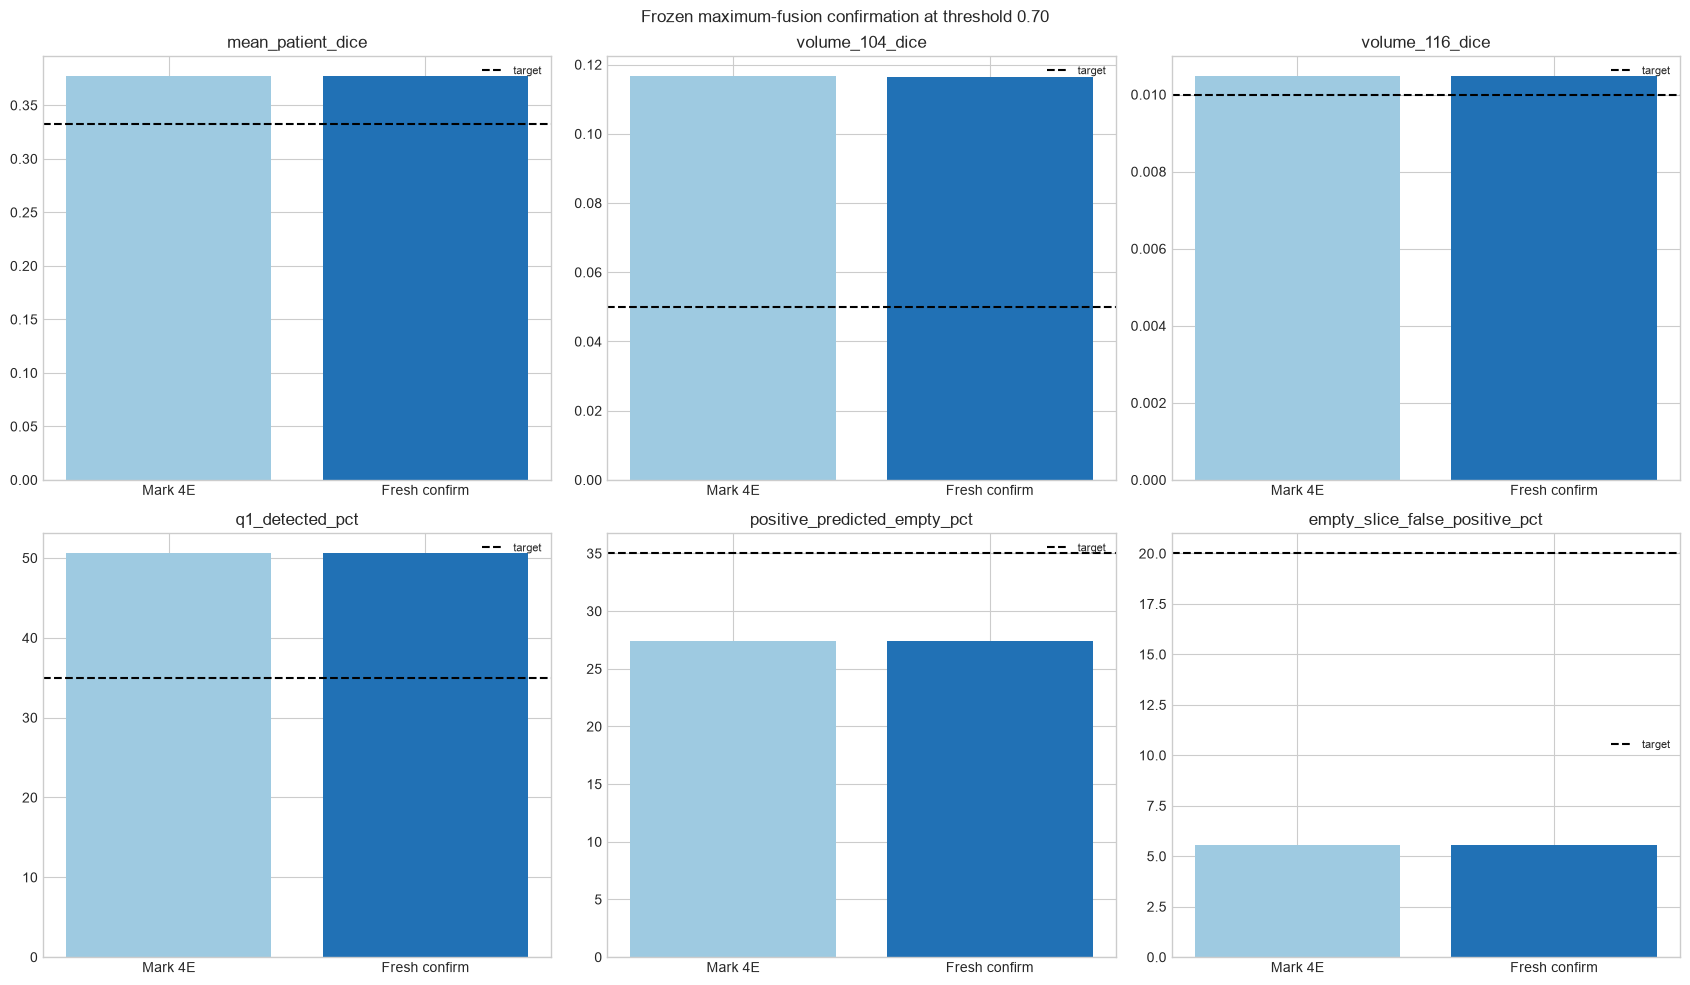

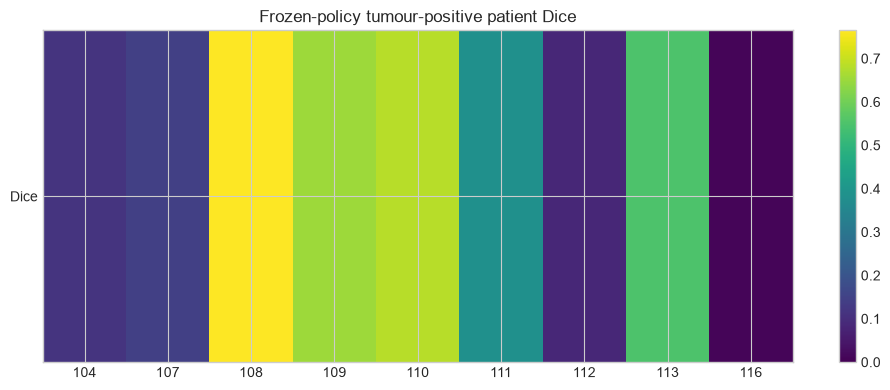

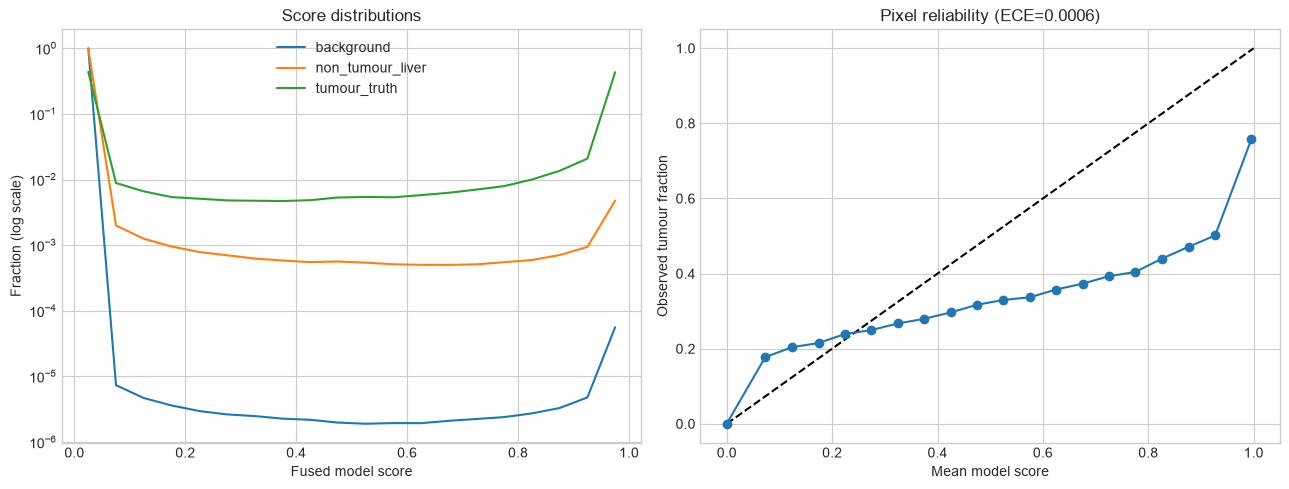

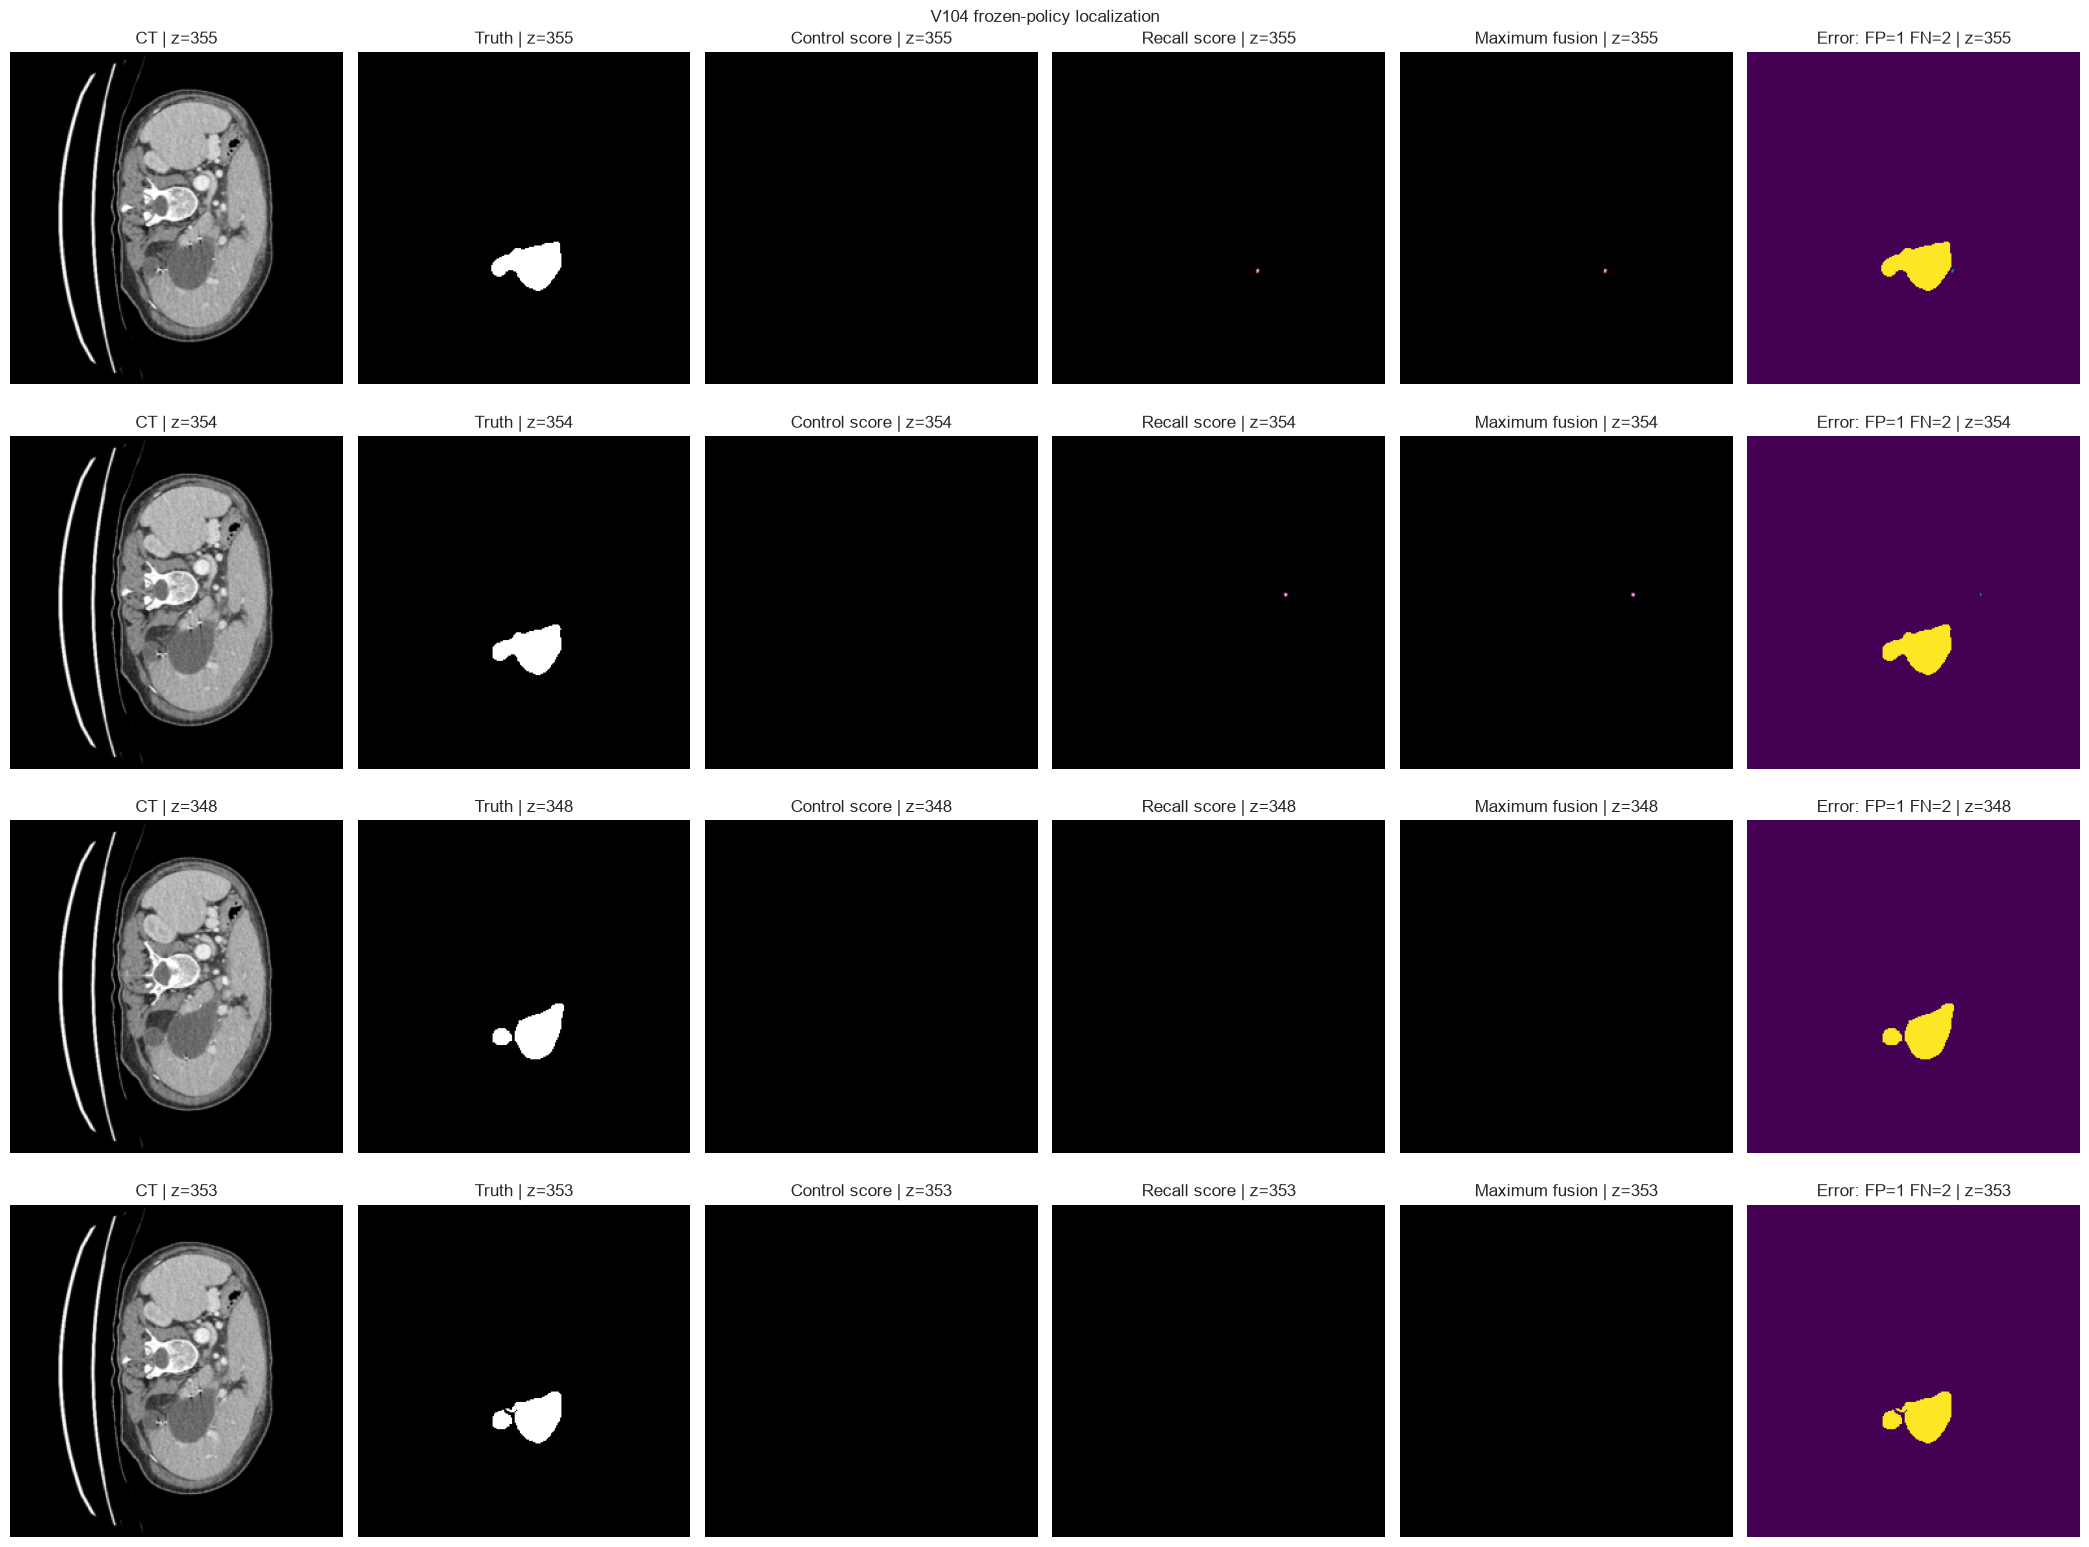

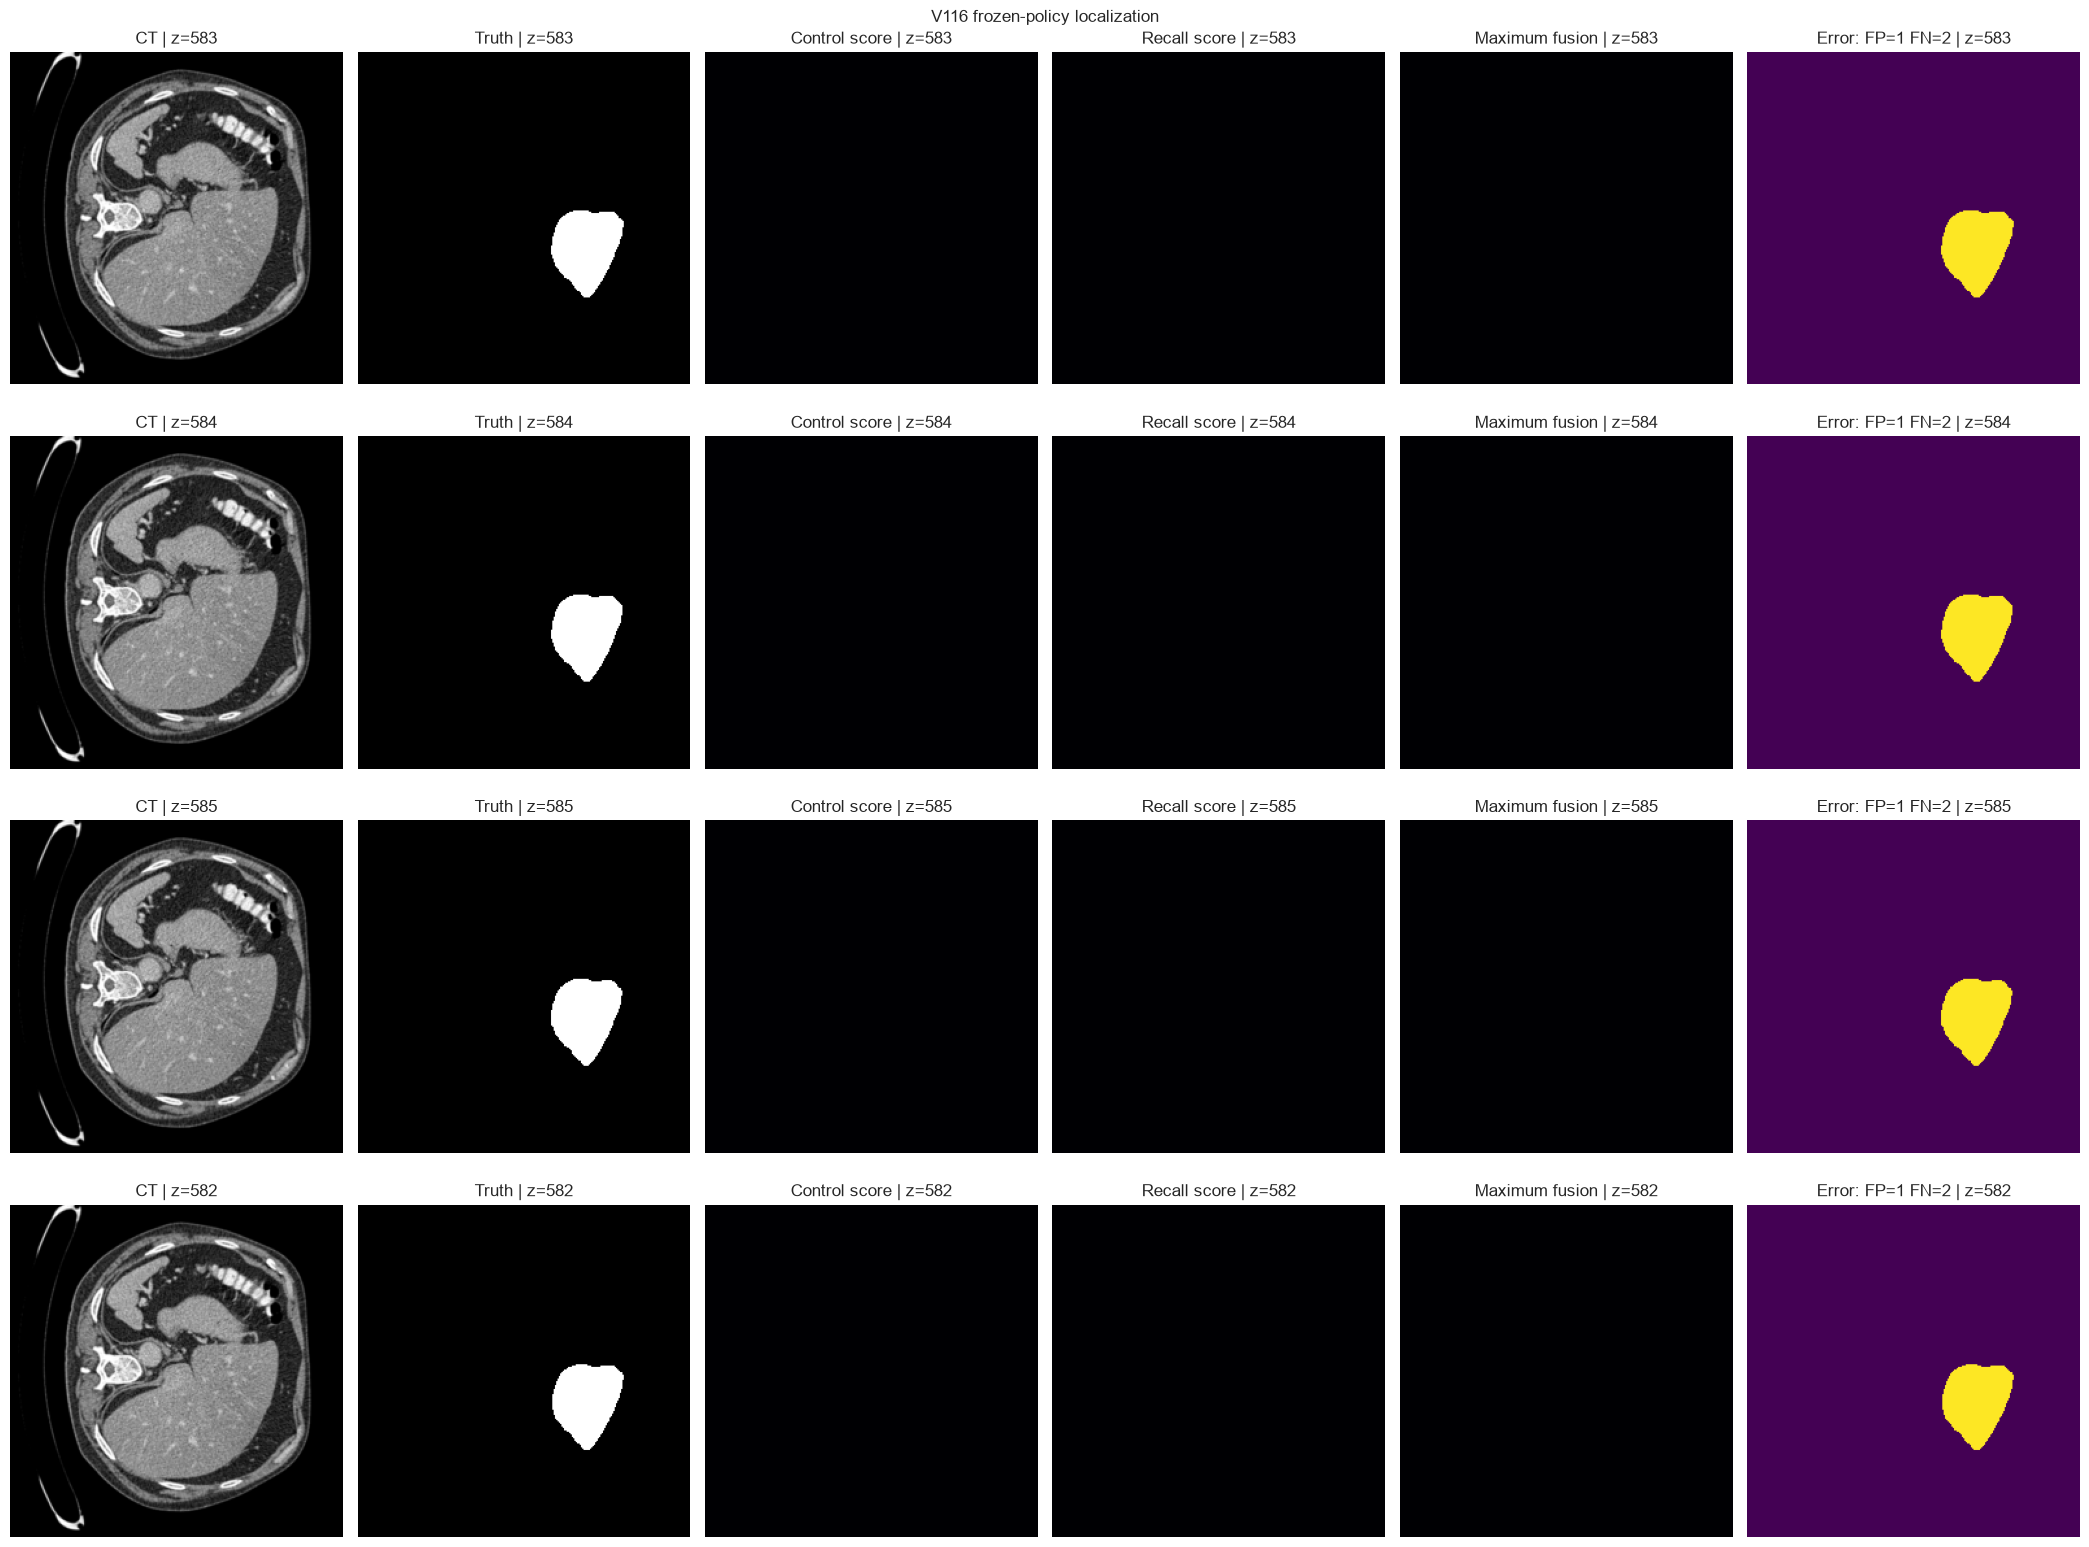

In [9]:
reference=json.loads((MARK4E_DIR/"mark_4e_gate_result.json").read_text(encoding="utf-8"))["selected_metrics"]
metric_names=list(TARGETS)
selected_values=np.array([selected[m] for m in metric_names],float); reference_values=np.array([reference[m] for m in metric_names],float)
fig,axes=plt.subplots(2,3,figsize=(17,10))
for ax,metric,current,prior in zip(axes.ravel(),metric_names,selected_values,reference_values):
    target=TARGETS[metric]; ax.bar(["Mark 4E","Fresh confirm"],[prior,current],color=["#9ecae1","#2171b5"]); ax.axhline(target,color="black",ls="--",label="target")
    ax.set_title(metric); ax.legend(fontsize=8)
fig.suptitle("Frozen maximum-fusion confirmation at threshold 0.70"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"fusion_confirmation_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()

positive=patients[patients.has_tumour].sort_values("volume_id")
fig,ax=plt.subplots(figsize=(10,4)); im=ax.imshow(positive[["dice"]].to_numpy().T,aspect="auto",cmap="viridis",vmin=0,vmax=max(.5,positive.dice.max()));
ax.set_xticks(range(len(positive)),positive.volume_id); ax.set_yticks([0],["Dice"]); ax.set_title("Frozen-policy tumour-positive patient Dice"); fig.colorbar(im,ax=ax); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"selected_policy_patient_heatmap.png",dpi=170,bbox_inches="tight"); plt.show()

fig,axes=plt.subplots(1,2,figsize=(13,5));
for category,group in histograms.groupby("category"):
    centres=(group.bin_left+group.bin_right)/2; axes[0].plot(centres,group["count"]/group["count"].sum(),label=category)
axes[0].set_yscale("log"); axes[0].set_xlabel("Fused model score"); axes[0].set_ylabel("Fraction (log scale)"); axes[0].legend(); axes[0].set_title("Score distributions")
axes[1].plot([0,1],[0,1],ls="--",c="black"); axes[1].plot(reliability.mean_score,reliability.observed_positive_fraction,marker="o"); axes[1].set_xlabel("Mean model score"); axes[1].set_ylabel("Observed tumour fraction"); axes[1].set_title(f"Pixel reliability (ECE={ece:.4f})")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"probability_diagnostics_dashboard.png",dpi=170,bbox_inches="tight"); plt.show()

lookup=val_rows.set_index("sample_id")
for focus_volume in [104,116]:
    with np.load(cache_paths[focus_volume],allow_pickle=False) as item:
        score=item["fused_probability"].astype(np.float32); truth=item["truth"].astype(bool); pred=score>=FROZEN_THRESHOLD
        sizes=truth.sum(axis=(1,2)); candidates=np.where(sizes>0)[0]; focus=candidates[np.argsort(sizes[candidates])[-4:]][::-1]
        fig,axes=plt.subplots(len(focus),6,figsize=(21,4*len(focus)),squeeze=False)
        for row_axes,i in zip(axes,focus):
            row=lookup.loc[str(item["sample_id"][i])]
            with Image.open(DATASET_ROOT/row.image_path) as handle: image=np.asarray(handle.convert("L"),dtype=np.float32)/255
            error=np.zeros((256,256),np.uint8); error[pred[i]&~truth[i]]=1; error[truth[i]&~pred[i]]=2
            panels=[(image,"CT","gray",0,1),(truth[i],"Truth","gray",0,1),(item["control_probability"][i],"Control score","magma",0,1),
                    (item["recall_probability"][i],"Recall score","magma",0,1),(score[i],"Maximum fusion","magma",0,1),(error,"Error: FP=1 FN=2","viridis",0,2)]
            for ax,(panel,title,cmap,vmin,vmax) in zip(row_axes,panels): ax.imshow(panel,cmap=cmap,vmin=vmin,vmax=vmax); ax.set_title(f"{title} | z={int(item['slice_index'][i])}"); ax.axis("off")
        fig.suptitle(f"V{focus_volume} frozen-policy localization"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/f"v{focus_volume}_localization.png",dpi=170,bbox_inches="tight"); plt.show()

### 10. Freeze the policy and write the validation decision

In [10]:
reference_deltas={metric:abs(float(selected[metric])-float(reference[metric])) for metric in TARGETS}
selected_gate=pd.DataFrame([{"metric":metric,"actual":float(selected[metric]),"target":target,"direction":"<=" if metric in LOWER_IS_BETTER else ">=",
    "passed":target_pass(metric,float(selected[metric])),"mark4e_reference":float(reference[metric]),"absolute_reference_delta":reference_deltas[metric]} for metric,target in TARGETS.items()])
save_csv(selected_gate,"selected_gate_table.csv")

mandatory_checks=[
    ("step01_dataset_gate",step01_gate["all_mandatory_targets_passed"],"Step 01 pass"),
    ("manifest_identity",manifest_hash==EXPECTED_MANIFEST_SHA256,manifest_hash),
    ("checkpoint_hashes_recorded",len(checkpoint_hashes)==2,checkpoint_hashes),
    ("fresh_historical_cache_equivalence",cache_equivalence_pass,{"aggregate_mean_abs":aggregate_cache_mean,"fraction_above_diagnostic_tolerance":aggregate_cache_fraction,"maximum_outlier_diagnostic":float(cache_equivalence.max_abs_difference.max())}),
    ("hard_prediction_equivalence",hard_equivalence_pass,aggregate_hard_disagreement),
    ("deterministic_repeated_inference",bool(determinism.passed.all()),float(determinism.max_abs_difference.max())),
    ("cache_integrity",bool(cache_integrity.finite.all() and cache_integrity.truth_shape_matches.all()),len(cache_integrity)),
    ("reference_metric_equivalence",max(reference_deltas.values())<=REFERENCE_METRIC_ABS_TOLERANCE,max(reference_deltas.values())),
    *[(f"target_{row.metric}",bool(row.passed),float(row.actual)) for row in selected_gate.itertuples()],
    ("bootstrap_reported",len(bootstrap_table)==1,bootstrap),
    ("v104_v116_localization_saved",(OUTPUT_DIR/"v104_localization.png").exists() and (OUTPUT_DIR/"v116_localization.png").exists(),"both panels"),
    ("test_images_accessed_false",TEST_IMAGES_ACCESSED is False,False)]
expected_vs_actual=pd.DataFrame(mandatory_checks,columns=["requirement","passed","actual"]); expected_vs_actual["expected"]="pass"; save_csv(expected_vs_actual,"expected_vs_actual.csv")
all_passed=bool(expected_vs_actual.passed.all())
if all_passed:
    result_level="VALIDATION_FREEZE_PASS"; decision="FREEZE_INFERENCE_POLICY_AND_REQUEST_FINAL_TEST_AUTHORIZATION"; next_step="step_03_final_inference_policy_freeze"
else:
    result_level="FAILED_GATE"; decision="STOP_DIAGNOSE_CONFIRMATION_FAILURE_NO_TEST"; next_step="diagnose_failed_confirmation_without_new_search"

immutable_policy={"status":"FROZEN" if all_passed else "NOT_FROZEN","dataset_build_id":"build_corrected_20260713_214847_v2",
    "manifest_sha256":manifest_hash,"checkpoint_paths":{k:str(v) for k,v in CHECKPOINTS.items()},"checkpoint_sha256":checkpoint_hashes,
    "input":{"channels":["broad_window"],"hu_window":[-160,240],"derived_normalization":"uint8/255"},
    "roi":{"source":"predicted_liver","threshold":.50,"component":"largest_3d","padding":16,"resize":[256,256],"inverse_mapping":"bilinear_to_frozen_box"},
    "score":"sigmoid(logit)","fusion":{"equation":"maximum(control_probability, recall_probability)"},"global_threshold":FROZEN_THRESHOLD,
    "post_processing":"none","metric_population":"nine tumour-positive validation patients for mean Dice","metric_epsilon":DICE_EPSILON,
    "software":{"python":sys.version,"platform":platform.platform(),"torch":torch.__version__,"numpy":np.__version__,"pandas":pd.__version__},
    "random_seed":RANDOM_SEED,"probability_cache":str(FRESH_CACHE_DIR),"test_images_accessed":False}
write_json(OUTPUT_DIR/"immutable_inference_policy.json",immutable_policy)

provenance={"created_utc":datetime.now(timezone.utc).isoformat(),"manifest_sha256":manifest_hash,"checkpoint_sha256":checkpoint_hashes,
    "input_artifact_hashes":{"step01_gate":sha256_file(STEP01_OUTPUTS/"pretraining_dataset_gate.json"),"mark4e_gate":sha256_file(MARK4E_DIR/"mark_4e_gate_result.json"),
        "validation_roi_manifest":sha256_file(VAL_ROI_PATH)},"validation_rows":len(val_rows),"validation_volumes":13,"positive_volumes":positive_volumes,
    "total_inference_seconds":total_seconds,"device":str(DEVICE),"test_metadata_rows_counted_only":len(test_metadata),"test_images_accessed":False}
write_json(OUTPUT_DIR/"provenance.json",provenance)
gate={"status":"fusion_confirmation_pass" if all_passed else "fusion_confirmation_fail","result_level":result_level,
    "selected_configuration":{"policy":FROZEN_POLICY,"threshold":FROZEN_THRESHOLD,"control_checkpoint_sha256":checkpoint_hashes["control"],"recall_checkpoint_sha256":checkpoint_hashes["recall_loss"]},
    "selected_metrics":{metric:float(selected[metric]) for metric in TARGETS},"uncertainty":{"mean_patient_dice":bootstrap},
    "targets":TARGETS,"target_passes":{row.metric:bool(row.passed) for row in selected_gate.itertuples()},
    "all_mandatory_targets_passed":all_passed,"decision":decision,"next_step":next_step,"manifest_sha256":manifest_hash,
    "input_artifact_hashes":provenance["input_artifact_hashes"],"test_images_accessed":False}
write_json(OUTPUT_DIR/"gate_result.json",gate)
configuration["full_analysis_executed"]=True; configuration["completed_utc"]=datetime.now(timezone.utc).isoformat(); write_json(OUTPUT_DIR/"configuration.json",configuration)
missing=[name for name in EXPECTED_OUTPUTS if not (OUTPUT_DIR/name).exists()]
if missing: raise RuntimeError(f"Output contract incomplete: {missing}")
print(json.dumps(gate,indent=2)); print("All required outputs exist.")

{
  "status": "fusion_confirmation_pass",
  "result_level": "VALIDATION_FREEZE_PASS",
  "selected_configuration": {
    "policy": "maximum",
    "threshold": 0.7,
    "control_checkpoint_sha256": "9b0c7749af66b0fc3808f6757d0d90af01384e06afe02090361b220df48b6e8b",
    "recall_checkpoint_sha256": "c01eb4b81e4e7f1d84c7966aca56e738d87d06d404907f0bcc7c67a79ed4ec4d"
  },
  "selected_metrics": {
    "mean_patient_dice": 0.3770605982242971,
    "volume_104_dice": 0.11647368422215168,
    "volume_116_dice": 0.010473419058478897,
    "q1_detected_pct": 50.57034220532319,
    "positive_predicted_empty_pct": 27.447216890595012,
    "empty_slice_false_positive_pct": 5.548065954578451
  },
  "uncertainty": {
    "mean_patient_dice": {
      "estimate": 0.3770605982242971,
      "ci_lower_2_5": 0.197929871077172,
      "ci_upper_97_5": 0.5542092886036671,
      "iterations": 10000,
      "resampling_unit": "tumour_positive_validation_patient",
      "seed": 42
    }
  },
  "targets": {
    "mean_pati

## Takeaways

Use `gate_result.json` as the controlling decision. `VALIDATION_FREEZE_PASS` permits creation of a final immutable inference-policy package and a request for explicit one-time test authorization; it does not itself authorize test access. Any failed mandatory check stops advancement and must be diagnosed without opening a new threshold/fusion search.